In [374]:
# Import necessary libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Define paths (update with your paths)
base_dir = r"S:\chexpert\chexpert-data"
train_csv = os.path.join(base_dir, "train_cheXbert.csv")

# Load CSV files
train_df = pd.read_csv(train_csv)

# Display first few rows of the training DataFrame
print("Training Data:")
print(train_df.head())


Training Data:
                                                Path     Sex  Age  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...  Female   68   
1  CheXpert-v1.0/train/patient00002/study2/view1_...  Female   87   
2  CheXpert-v1.0/train/patient00002/study1/view1_...  Female   83   
3  CheXpert-v1.0/train/patient00002/study1/view2_...  Female   83   
4  CheXpert-v1.0/train/patient00003/study1/view1_...    Male   41   

  Frontal/Lateral AP/PA  Enlarged Cardiomediastinum  Cardiomegaly  \
0         Frontal    AP                         NaN           NaN   
1         Frontal    AP                         NaN           1.0   
2         Frontal    AP                         NaN           NaN   
3         Lateral   NaN                         NaN           NaN   
4         Frontal    AP                         NaN           NaN   

   Lung Opacity  Lung Lesion  Edema  Consolidation  Pneumonia  Atelectasis  \
0           NaN          NaN    NaN            NaN        NaN          NaN   

In [375]:
print("Columns in Training Data:", train_df.columns)

Columns in Training Data: Index(['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA',
       'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity',
       'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
       'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture',
       'Support Devices', 'No Finding'],
      dtype='object')


In [376]:
# Define conditions dynamically by excluding non-pathology columns
non_pathology_columns = ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA']
conditions = [col for col in train_df.columns if col not in non_pathology_columns]

# Print the dynamically created list of conditions
print("Conditions:", conditions)

Conditions: ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices', 'No Finding']


In [377]:
print("Missing Values in Training Data:")
print(train_df.isnull().sum())

Missing Values in Training Data:
Path                               0
Sex                                0
Age                                0
Frontal/Lateral                    0
AP/PA                          32387
Enlarged Cardiomediastinum    178223
Cardiomegaly                  172776
Lung Opacity                  114911
Lung Lesion                   211146
Edema                         136902
Consolidation                 151520
Pneumonia                     195858
Atelectasis                   154406
Pneumothorax                  144447
Pleural Effusion               90188
Pleural Other                 216586
Fracture                      210274
Support Devices               106137
No Finding                    202290
dtype: int64


In [378]:
# new subset of training data without lateral and PA views
sub_train_df = train_df[train_df['Frontal/Lateral'] == 'Frontal']
sub_train_df = train_df[train_df['AP/PA'] == 'AP']

# Display first few rows of the training DataFrame
print("Training Data:")
sub_train_df.head()


Training Data:


,Path,Sex,Age,Frontal/Lateral,AP/PA,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,CheXpert-v1.0/train/patient00001/study1/view1_...,Female,68,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,1.0
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,NaN,1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,NaN
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN
9,CheXpert-v1.0/train/patient00005/study2/view1_...,Male,33,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN


In [379]:
#total number of images
total_images = len(train_df)
print("Total Images:", total_images)

Total Images: 223414


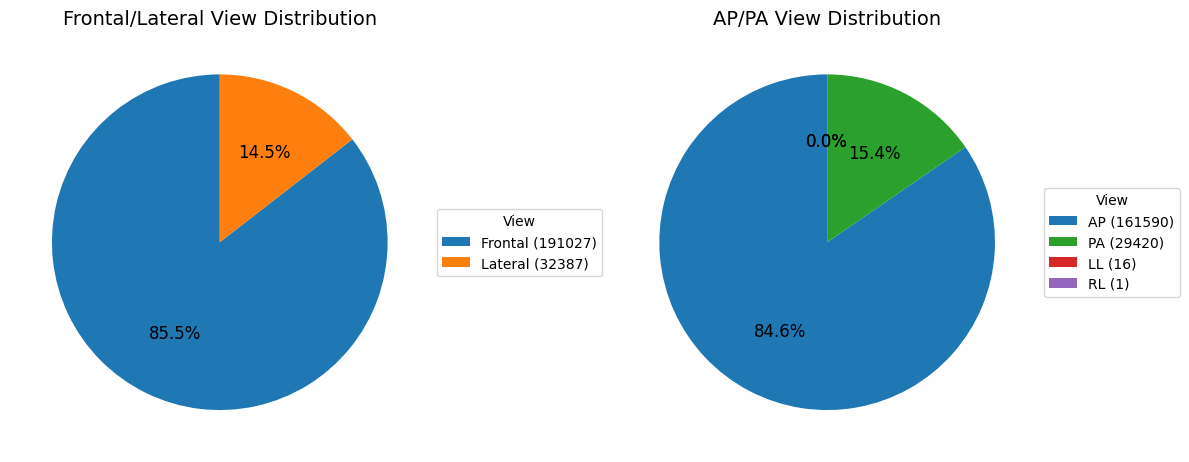

In [348]:
import matplotlib.pyplot as plt

# Define colors
colors1 = ['#1f77b4', '#ff7f0e']           # Frontal/Lateral
colors2 = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # AP/PA categories (excluding "0")

# Create figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- Frontal/Lateral View Distribution ---
# Get counts and labels
fl_counts = train_df["Frontal/Lateral"].value_counts()
# Create pie chart without slice labels (the labels will be in the legend)
wedges_fl, texts_fl, autotexts_fl = ax[0].pie(
    fl_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 12}
)
ax[0].set_title('Frontal/Lateral View Distribution', fontsize=14)
ax[0].set_ylabel("")

# Build custom legend labels: "Category (count)"
legend_labels_fl = [f"{label} ({count})" for label, count in zip(fl_counts.index, fl_counts)]
ax[0].legend(
    wedges_fl, legend_labels_fl, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

# --- AP/PA View Distribution (Excluding "0" by filtering only Frontal views) ---
# Get counts and labels
ap_pa_counts = train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()
# Create pie chart
wedges_ap_pa, texts_ap_pa, autotexts_ap_pa = ax[1].pie(
    ap_pa_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12}
)
ax[1].set_title('AP/PA View Distribution', fontsize=14)
ax[1].set_ylabel("")

# Build custom legend labels for AP/PA
legend_labels_ap_pa = [f"{label} ({count})" for label, count in zip(ap_pa_counts.index, ap_pa_counts)]
ax[1].legend(
    wedges_ap_pa, legend_labels_ap_pa, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

C:\Users\soapy\AppData\Local\Temp\ipykernel_23912\2535719523.py:33: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ap_pa_counts = sub_train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()


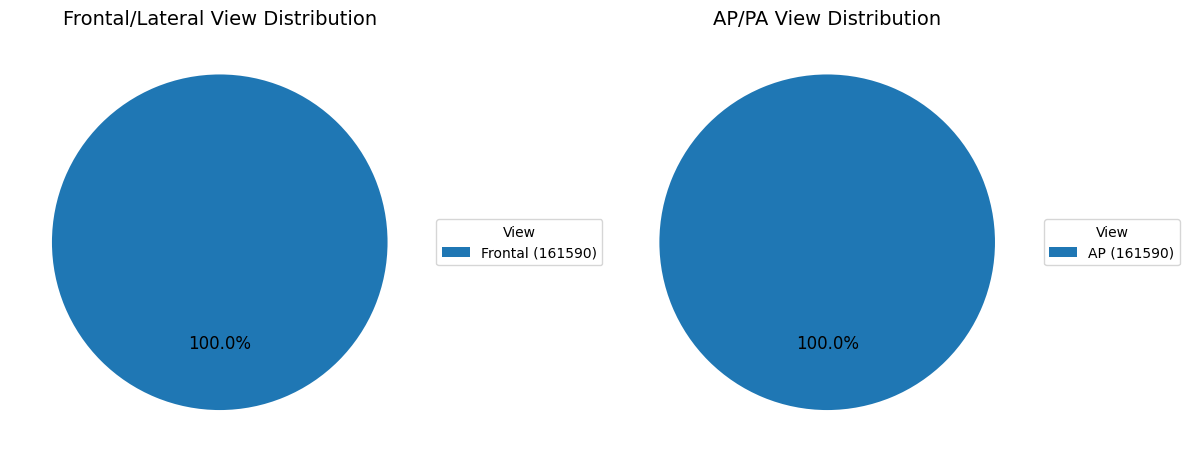

In [380]:
import matplotlib.pyplot as plt

# Define colors
colors1 = ['#1f77b4', '#ff7f0e']           # Frontal/Lateral
colors2 = ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']  # AP/PA categories (excluding "0")

# Create figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# --- Frontal/Lateral View Distribution ---
# Get counts and labels
fl_counts = sub_train_df["Frontal/Lateral"].value_counts()
# Create pie chart without slice labels (the labels will be in the legend)
wedges_fl, texts_fl, autotexts_fl = ax[0].pie(
    fl_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors1,
    textprops={'fontsize': 12}
)
ax[0].set_title('Frontal/Lateral View Distribution', fontsize=14)
ax[0].set_ylabel("")

# Build custom legend labels: "Category (count)"
legend_labels_fl = [f"{label} ({count})" for label, count in zip(fl_counts.index, fl_counts)]
ax[0].legend(
    wedges_fl, legend_labels_fl, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

# --- AP/PA View Distribution (Excluding "0" by filtering only Frontal views) ---
# Get counts and labels
ap_pa_counts = sub_train_df[train_df["Frontal/Lateral"] == "Frontal"]["AP/PA"].value_counts()
# Create pie chart
wedges_ap_pa, texts_ap_pa, autotexts_ap_pa = ax[1].pie(
    ap_pa_counts.values,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors2,
    textprops={'fontsize': 12}
)
ax[1].set_title('AP/PA View Distribution', fontsize=14)
ax[1].set_ylabel("")

# Build custom legend labels for AP/PA
legend_labels_ap_pa = [f"{label} ({count})" for label, count in zip(ap_pa_counts.index, ap_pa_counts)]
ax[1].legend(
    wedges_ap_pa, legend_labels_ap_pa, title="View", 
    loc="center left", bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.tight_layout()
plt.show()

Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum       22527.0        7611.0         15053.0   
Cardiomegaly                     16155.0       30566.0          3917.0   
Lung Opacity                      5096.0      103092.0           315.0   
Lung Lesion                       1349.0        9346.0          1573.0   
Edema                            21243.0       53058.0         12211.0   
Consolidation                    31523.0       13682.0         26689.0   
Pneumonia                         3314.0        4856.0         19386.0   
Atelectasis                        730.0       33862.0         34416.0   
Pneumothorax                     58663.0       17869.0          2435.0   
Pleural Effusion                 36278.0       89314.0          7634.0   
Pleural Other                      138.0        3959.0          2731.0   
Fracture                          3937.0        8701.0           502.0   
Support

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

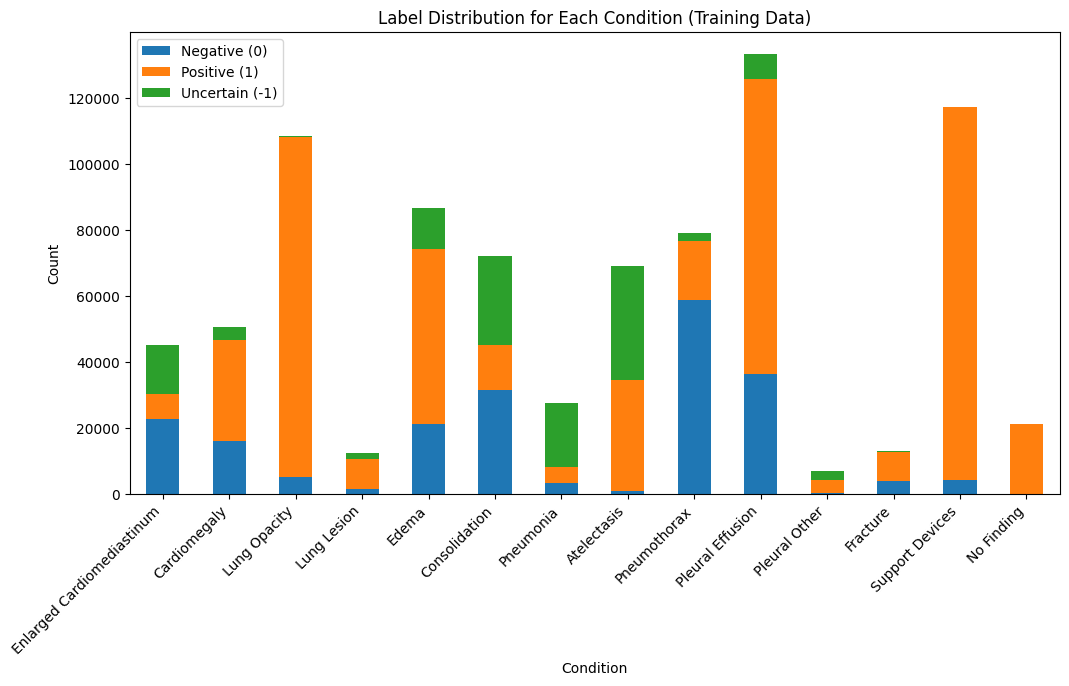

In [350]:
# Count occurrences of each label value and reindex to include all possible categories
label_counts = train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

# Visualize the label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition (Training Data)")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)
plt.xlabel("Condition")
plt.legend(loc="upper left")
plt.xticks(rotation=45)

Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum        9761.0        5457.0         10679.0   
Cardiomegaly                      6840.0       22896.0          2881.0   
Lung Opacity                      2858.0       83340.0           158.0   
Lung Lesion                        222.0        4953.0           860.0   
Edema                            11748.0       48850.0         10376.0   
Consolidation                    13306.0       10931.0         21400.0   
Pneumonia                         1053.0        2792.0         14329.0   
Atelectasis                        344.0       26945.0         27150.0   
Pneumothorax                     41007.0       14598.0          2060.0   
Pleural Effusion                 15837.0       71388.0          5201.0   
Pleural Other                       42.0        1652.0          1084.0   
Fracture                          2191.0        5826.0           291.0   
Support

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

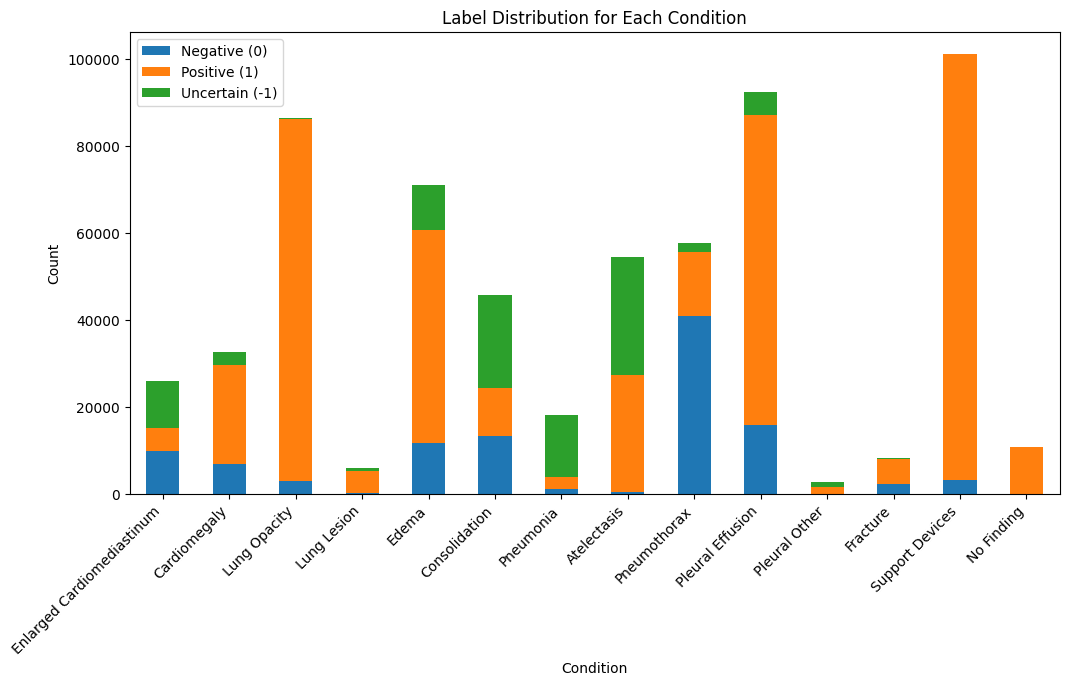

In [351]:
# label distribution for the subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

# Visualize the label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

In [381]:
# subset of training data where N/A values are replaced with 0
sub_train_df.fillna(0, inplace=True)

C:\Users\soapy\AppData\Local\Temp\ipykernel_23912\717220722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_train_df.fillna(0, inplace=True)


In [383]:
print("Missing Values in Training Data:")
print(sub_train_df.isnull().sum())

Missing Values in Training Data:
Path                          0
Sex                           0
Age                           0
Frontal/Lateral               0
AP/PA                         0
Enlarged Cardiomediastinum    0
Cardiomegaly                  0
Lung Opacity                  0
Lung Lesion                   0
Edema                         0
Consolidation                 0
Pneumonia                     0
Atelectasis                   0
Pneumothorax                  0
Pleural Effusion              0
Pleural Other                 0
Fracture                      0
Support Devices               0
No Finding                    0
dtype: int64


Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum      145454.0        5457.0         10679.0   
Cardiomegaly                    135813.0       22896.0          2881.0   
Lung Opacity                     78092.0       83340.0           158.0   
Lung Lesion                     155777.0        4953.0           860.0   
Edema                           102364.0       48850.0         10376.0   
Consolidation                   129259.0       10931.0         21400.0   
Pneumonia                       144469.0        2792.0         14329.0   
Atelectasis                     107495.0       26945.0         27150.0   
Pneumothorax                    144932.0       14598.0          2060.0   
Pleural Effusion                 85001.0       71388.0          5201.0   
Pleural Other                   158854.0        1652.0          1084.0   
Fracture                        155473.0        5826.0           291.0   
Support

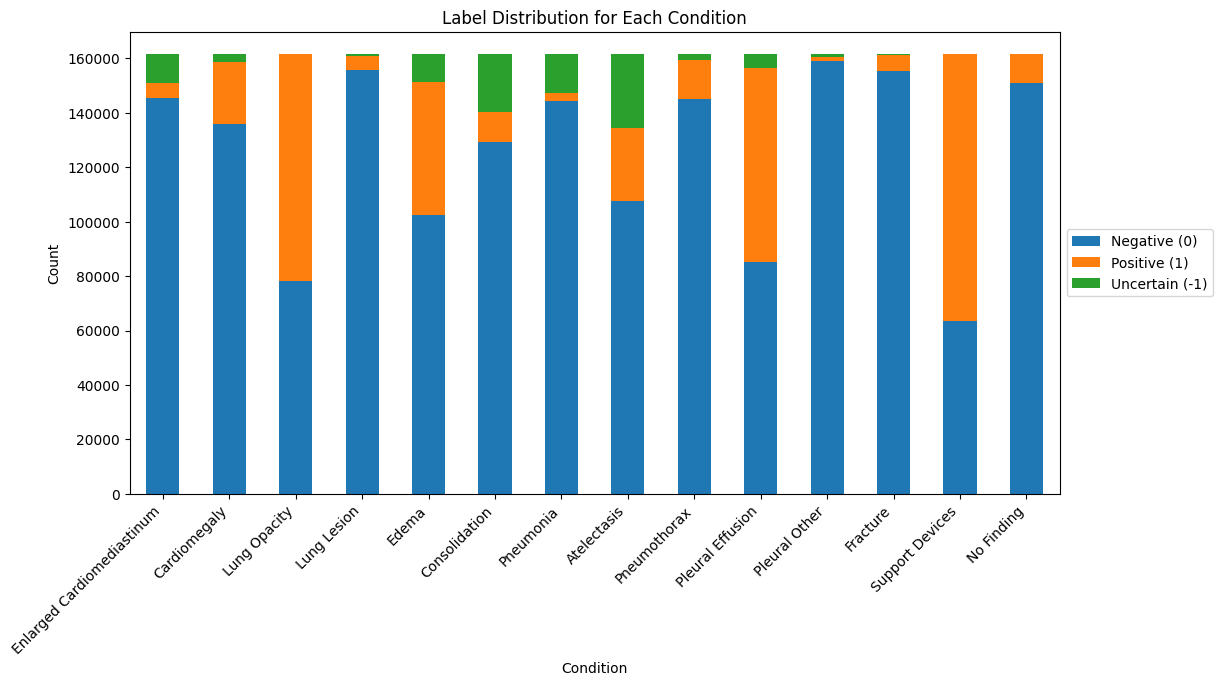

In [384]:
# label distribution for the subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

# Visualize the label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

# legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

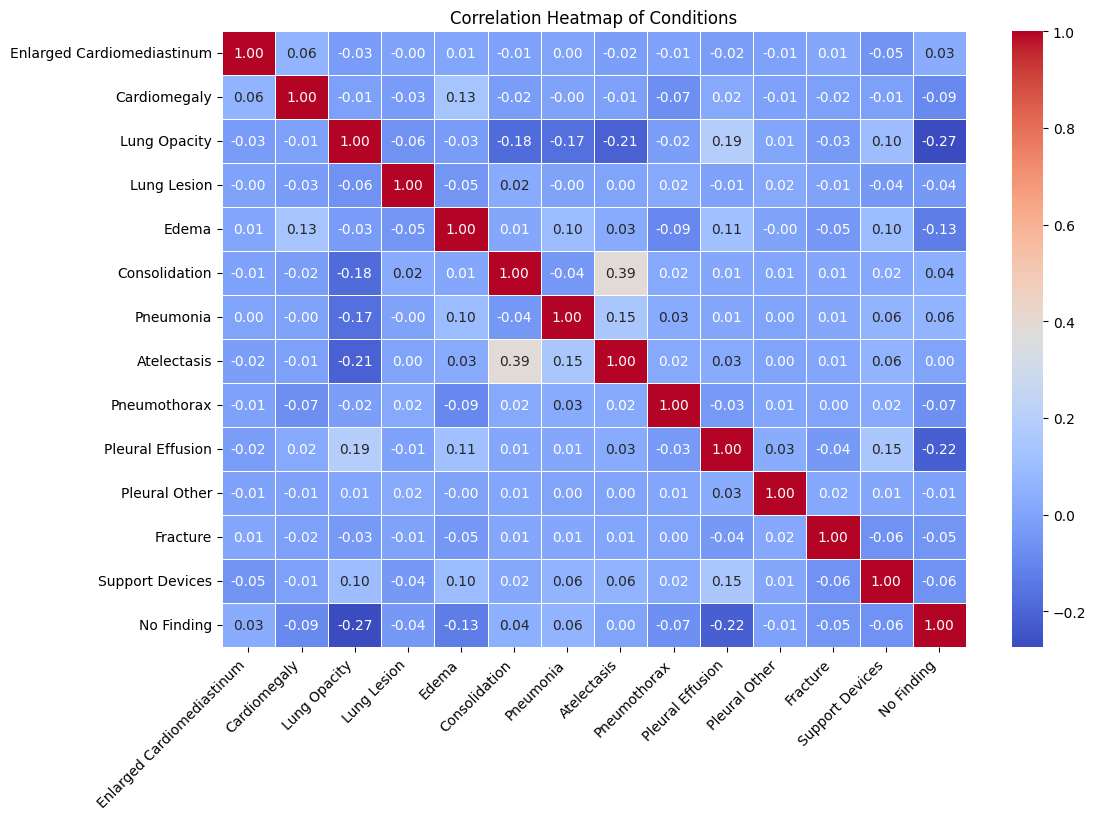

In [370]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
correlation_matrix = sub_train_df[conditions].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5)
plt.title("Correlation Heatmap of Conditions")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [385]:
# correlation values for the subset of training data in descending order
correlation_values = correlation_matrix.unstack().sort_values(ascending=False)
correlation_values = correlation_values[correlation_values != 1]  # Exclude self-correlations

# Display the top 10 most positively and negatively correlated pairs in dataframe
print("Top 20 Most Positively Correlated Pairs:")
correlation_df = pd.DataFrame(correlation_values, columns=["Correlation"])
correlation_df.head(20)


Top 20 Most Positively Correlated Pairs:


,,Correlation
Consolidation,Atelectasis,0.387104
Atelectasis,Consolidation,0.387104
Pleural Effusion,Lung Opacity,0.190834
Lung Opacity,Pleural Effusion,0.190834
Pleural Effusion,Support Devices,0.152969
Support Devices,Pleural Effusion,0.152969
Pneumonia,Atelectasis,0.149331
Atelectasis,Pneumonia,0.149331
Cardiomegaly,Edema,0.134712
Edema,Cardiomegaly,0.134712


Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum      145454.0        5457.0         10679.0   
Cardiomegaly                    135813.0       22896.0          2881.0   
Lung Opacity                     78092.0       83340.0           158.0   
Lung Lesion                     155777.0        4953.0           860.0   
Edema                           102364.0       48850.0         10376.0   
Consolidation                   129259.0       10931.0         21400.0   
Pneumonia                       144469.0        2792.0         14329.0   
Atelectasis                     107495.0       26945.0         27150.0   
Pneumothorax                    144932.0       14598.0          2060.0   
Pleural Effusion                 85001.0       71388.0          5201.0   
Pleural Other                   158854.0        1652.0          1084.0   
Fracture                        155473.0        5826.0           291.0   
Support

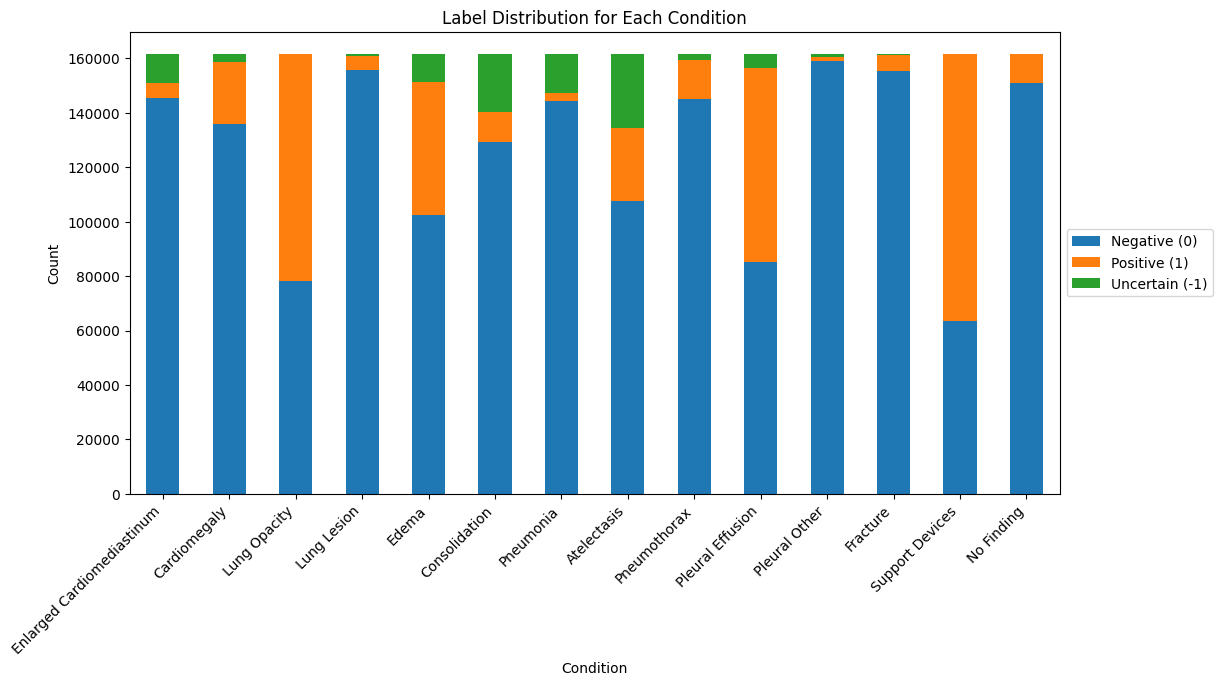

In [387]:
# label distribution for the subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

# Visualize the label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

# legend outside the plot
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [386]:
print(sub_train_df[conditions].isna().sum())

Enlarged Cardiomediastinum    0
Cardiomegaly                  0
Lung Opacity                  0
Lung Lesion                   0
Edema                         0
Consolidation                 0
Pneumonia                     0
Atelectasis                   0
Pneumothorax                  0
Pleural Effusion              0
Pleural Other                 0
Fracture                      0
Support Devices               0
No Finding                    0
dtype: int64


In [311]:
# how many null values are there in the subset of training data
print("Missing Values in Training Data:")
print(sub_train_df.isnull().sum())

# nulls out of total
print("Nulls out of Total:")
print(sub_train_df.isnull().sum() / len(sub_train_df))

Missing Values in Training Data:
Path                               0
Sex                                0
Age                                0
Frontal/Lateral                    0
AP/PA                              0
Enlarged Cardiomediastinum    135693
Cardiomegaly                  128973
Lung Opacity                   75234
Lung Lesion                   155555
Edema                          90616
Consolidation                 115953
Pneumonia                     143416
Atelectasis                   107151
Pneumothorax                  103925
Pleural Effusion               69164
Pleural Other                 158812
Fracture                      153282
Support Devices                60428
No Finding                    150803
dtype: int64
Nulls out of Total:
Path                          0.000000
Sex                           0.000000
Age                           0.000000
Frontal/Lateral               0.000000
AP/PA                         0.000000
Enlarged Cardiomediastinum    0.8397

In [319]:
# change the null values to 0
sub_train_df.fillna(0, inplace=True)

C:\Users\soapy\AppData\Local\Temp\ipykernel_23912\4159845553.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_train_df.fillna(0, inplace=True)


Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
Enlarged Cardiomediastinum      145454.0        5457.0         10679.0   
Cardiomegaly                    135813.0       22896.0          2881.0   
Lung Opacity                     78092.0       83340.0           158.0   
Lung Lesion                     155777.0        4953.0           860.0   
Edema                           102364.0       48850.0         10376.0   
Consolidation                   129259.0       10931.0         21400.0   
Pneumonia                       144469.0        2792.0         14329.0   
Atelectasis                     107495.0       26945.0         27150.0   
Pneumothorax                    144932.0       14598.0          2060.0   
Pleural Effusion                 85001.0       71388.0          5201.0   
Pleural Other                   158854.0        1652.0          1084.0   
Fracture                        155473.0        5826.0           291.0   
Support

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

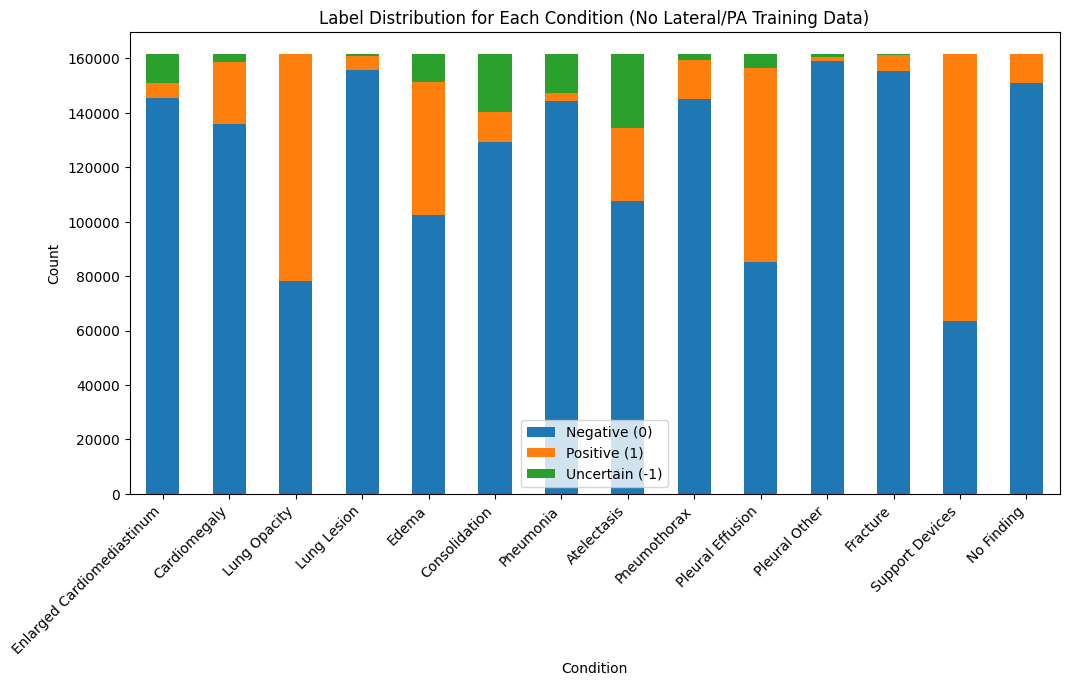

In [320]:
# label distribution for the subset of training data
label_counts = sub_train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

# Visualize the label distribution
label_counts.drop(columns="Unmentioned (NaN)").plot(kind="bar", figsize=(12, 6), stacked=True)
plt.title("Label Distribution for Each Condition (No Lateral/PA Training Data)")
plt.ylabel("Count")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)
plt.xlabel("Condition")
plt.xticks(rotation=45)

                            Missing (%)  Uncertain (%)
Pleural Other                 96.943790       1.222394
Lung Lesion                   94.508849       0.704074
Fracture                      94.118542       0.224695
No Finding                    90.544908       0.000000
Pneumonia                     87.665948       8.677164
Enlarged Cardiomediastinum    79.772530       6.737716
Cardiomegaly                  77.334455       1.753247
Atelectasis                   69.112052      15.404585
Consolidation                 67.820280      11.945984
Pneumothorax                  64.654408       1.089905
Edema                         61.277270       5.465638
Lung Opacity                  51.434109       0.140994
Support Devices               47.506871       0.024618
Pleural Effusion              40.368106       3.416975


([<matplotlib.axis.XTick at 0x2272a1b7740>,
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

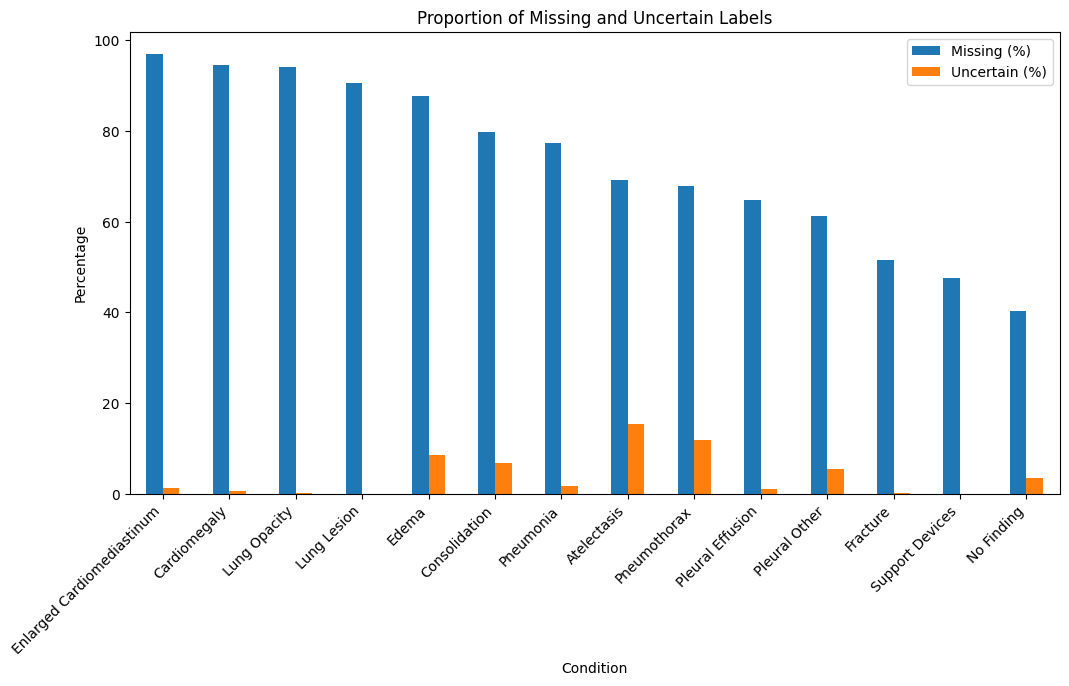

In [312]:
# Calculate proportions of missing and uncertain labels
missing_proportion = train_df[conditions].isnull().mean() * 100
uncertain_proportion = (train_df[conditions] == -1).mean() * 100

# Combine results into a DataFrame
eda_summary = pd.DataFrame({
    "Missing (%)": missing_proportion,
    "Uncertain (%)": uncertain_proportion
}).sort_values(by="Missing (%)", ascending=False)

print(eda_summary)

# Plot missing and uncertain proportions
eda_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Proportion of Missing and Uncertain Labels")
plt.ylabel("Percentage")
plt.xlabel("Condition")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)

                            Missing (%)  Uncertain (%)
Pleural Other                 98.280834       0.670834
Lung Lesion                   96.265239       0.532211
Fracture                      94.858593       0.180085
No Finding                    93.324463       0.000000
Pneumonia                     88.753017       8.867504
Enlarged Cardiomediastinum    83.973637       6.608701
Cardiomegaly                  79.814964       1.782907
Consolidation                 71.757535      13.243394
Atelectasis                   66.310415      16.801782
Pneumothorax                  64.314005       1.274831
Edema                         56.077728       6.421189
Lung Opacity                  46.558574       0.097778
Pleural Effusion              42.802154       3.218640
Support Devices               37.395878       0.032799


([<matplotlib.axis.XTick at 0x22723ef3e60>,
 [Text(0, 0, 'Enlarged Cardiomediastinum'),
  Text(1, 0, 'Cardiomegaly'),
  Text(2, 0, 'Lung Opacity'),
  Text(3, 0, 'Lung Lesion'),
  Text(4, 0, 'Edema'),
  Text(5, 0, 'Consolidation'),
  Text(6, 0, 'Pneumonia'),
  Text(7, 0, 'Atelectasis'),
  Text(8, 0, 'Pneumothorax'),
  Text(9, 0, 'Pleural Effusion'),
  Text(10, 0, 'Pleural Other'),
  Text(11, 0, 'Fracture'),
  Text(12, 0, 'Support Devices'),
  Text(13, 0, 'No Finding')])

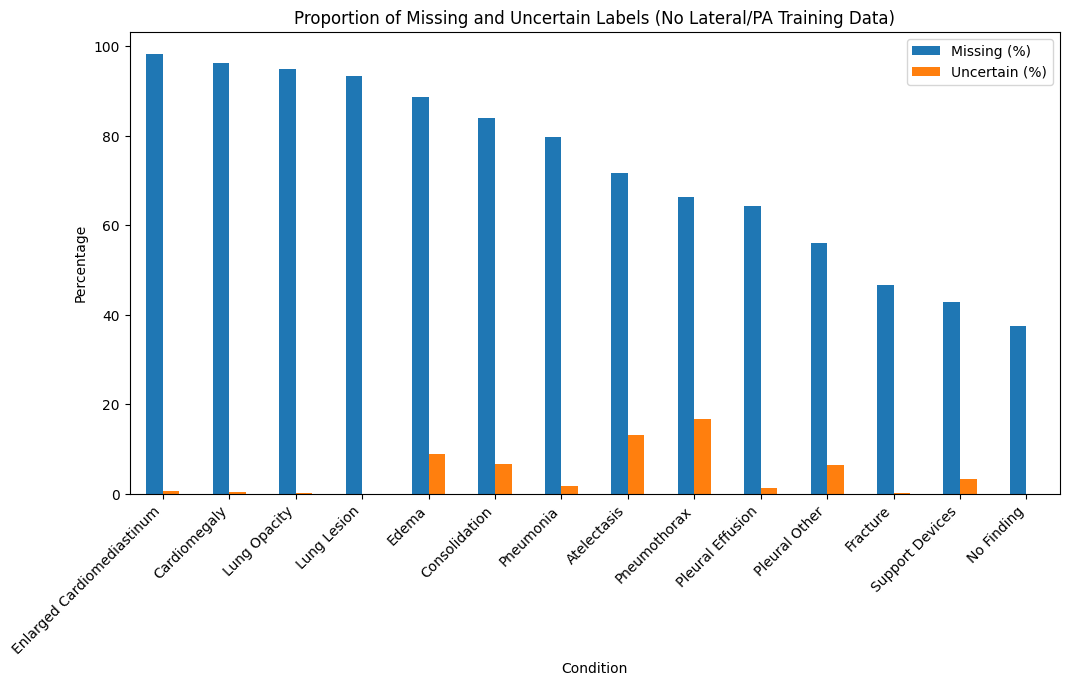

In [313]:
# Calculate proportions of missing and uncertain labels for the subset of training data
missing_proportion = sub_train_df[conditions].isnull().mean() * 100
uncertain_proportion = (sub_train_df[conditions] == -1).mean() * 100


# Combine results into a DataFrame
sub_eda_summary = pd.DataFrame({
    "Missing (%)": missing_proportion,
    "Uncertain (%)": uncertain_proportion
}).sort_values(by="Missing (%)", ascending=False)

print(sub_eda_summary)

# Plot missing and uncertain proportions
sub_eda_summary.plot(kind="bar", figsize=(12, 6))
plt.title("Proportion of Missing and Uncertain Labels (No Lateral/PA Training Data)")
plt.ylabel("Percentage")
plt.xlabel("Condition")
plt.xticks(
    ticks=range(len(label_counts.index)),  # Set ticks to match bar positions
    labels=label_counts.index,            # Set labels to condition names
    rotation=45,                          # Rotate for better readability
    ha="right"                            # Align labels to the right for better clarity
)

Sex Distribution:
Sex
Male       132636
Female      90777
Unknown         1
Name: count, dtype: int64


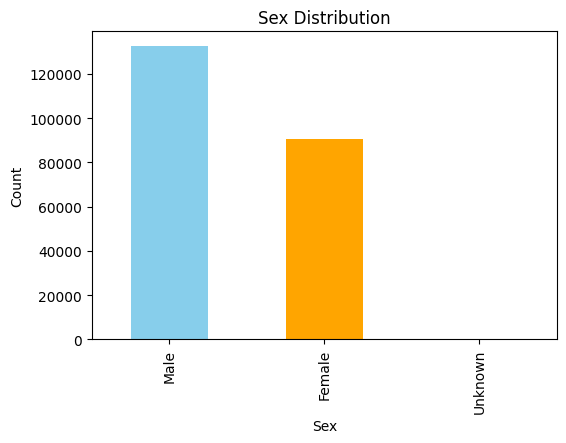

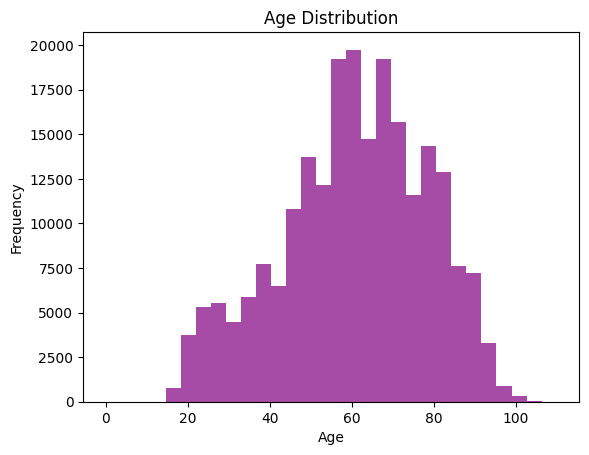

In [314]:
# Sex distribution
print("Sex Distribution:")
print(train_df["Sex"].value_counts())

# Plot Sex Distribution
train_df["Sex"].value_counts().plot(kind="bar", figsize=(6, 4), color=["skyblue", "orange"])
plt.title("Sex Distribution")
plt.ylabel("Count")
plt.xlabel("Sex")
plt.show()

# Age distribution
plt.hist(train_df["Age"].dropna(), bins=30, alpha=0.7, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Sex Distribution:
Sex
Male      92854
Female    68736
Name: count, dtype: int64


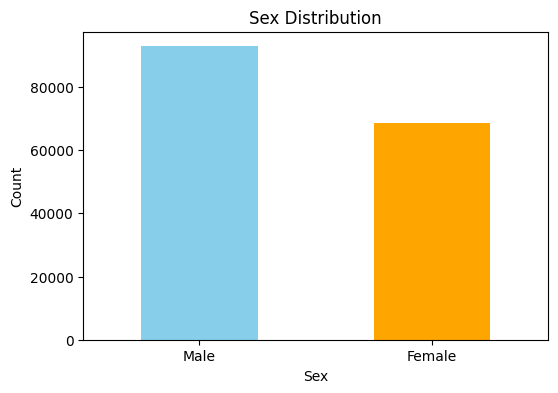

Age Distribution:
Age
61     3865
66     3728
58     3640
64     3637
65     3612
       ... 
108       3
0         3
107       2
109       1
105       1
Name: count, Length: 94, dtype: int64


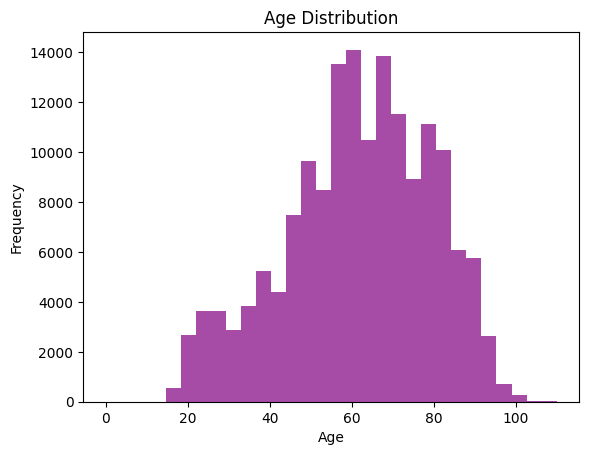

In [328]:
# sex distribution for the subset of training data
print("Sex Distribution:")
print(sub_train_df["Sex"].value_counts())

sub_train_df["Sex"].value_counts().plot(kind="bar", figsize=(6, 4), color=["skyblue", "orange"])
plt.title("Sex Distribution")
plt.ylabel("Count")
plt.xlabel("Sex")
plt.xticks(rotation=0)  # Ensures labels are horizontal
plt.show()

# age distribution for the subset of training data
print("Age Distribution:")
print(sub_train_df["Age"].value_counts())

plt.hist(sub_train_df["Age"].dropna(), bins=30, alpha=0.7, color="purple")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Frontal/Lateral Distribution:
Frontal/Lateral
Frontal    191027
Lateral     32387
Name: count, dtype: int64


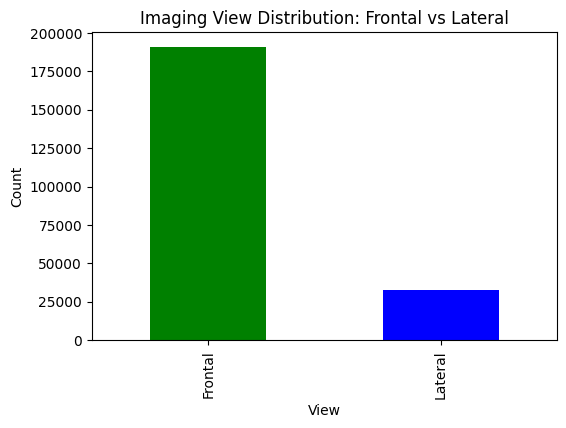

AP/PA Distribution:
AP/PA
AP    161590
PA     29420
LL        16
RL         1
Name: count, dtype: int64


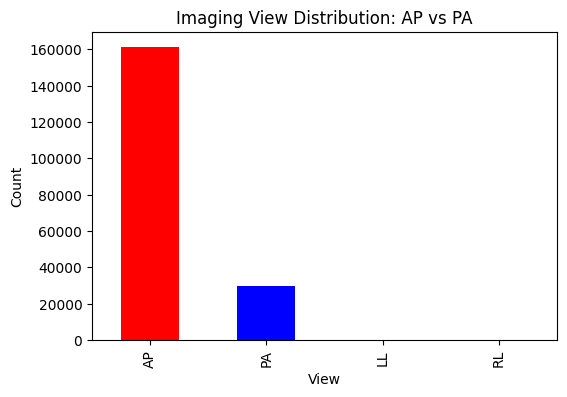

In [316]:
# Frontal/Lateral Distribution
print("Frontal/Lateral Distribution:")
print(train_df["Frontal/Lateral"].value_counts())

# Plot Frontal/Lateral Distribution
train_df["Frontal/Lateral"].value_counts().plot(kind="bar", figsize=(6, 4), color=["green", "blue"])
plt.title("Imaging View Distribution: Frontal vs Lateral")
plt.ylabel("Count")
plt.xlabel("View")
plt.show()

# AP/PA Distribution
print("AP/PA Distribution:")
print(train_df["AP/PA"].value_counts())

# Plot AP/PA Distribution
train_df["AP/PA"].value_counts().plot(kind="bar", figsize=(6, 4), color=["red", "blue"])
plt.title("Imaging View Distribution: AP vs PA")
plt.ylabel("Count")
plt.xlabel("View")
plt.show()

In [317]:
# front/lateral distribution for the subset of training data
print("Frontal/Lateral Distribution:")
print(sub_train_df["Frontal/Lateral"].value_counts())

# ap/pa distribution for the subset of training data
print("AP/PA Distribution:")    
print(sub_train_df["AP/PA"].value_counts())

Frontal/Lateral Distribution:
Frontal/Lateral
Frontal    161590
Name: count, dtype: int64
AP/PA Distribution:
AP/PA
AP    161590
Name: count, dtype: int64


In [325]:
# Define the base directory for training images
image_base_dir = r"S:\chexpert\chexpert-data\train_images"

# Update the middle portion of the path
train_df["ImagePath"] = train_df["Path"].apply(
    lambda x: os.path.normpath(x.replace("CheXpert-v1.0/train", image_base_dir))
)

# Verify the paths and check for missing images
train_df["Exists"] = train_df["ImagePath"].apply(lambda x: os.path.exists(x))

# Display missing images, if any
missing_images = train_df[~train_df["Exists"]]
print(f"Number of missing images: {len(missing_images)}")

# Preview the corrected paths
print(train_df[["Path", "ImagePath", "Exists"]].head())

Number of missing images: 0
                                                Path  \
0  CheXpert-v1.0/train/patient00001/study1/view1_...   
1  CheXpert-v1.0/train/patient00002/study2/view1_...   
2  CheXpert-v1.0/train/patient00002/study1/view1_...   
3  CheXpert-v1.0/train/patient00002/study1/view2_...   
4  CheXpert-v1.0/train/patient00003/study1/view1_...   

                                           ImagePath  Exists  
0  S:\chexpert\chexpert-data\train_images\patient...    True  
1  S:\chexpert\chexpert-data\train_images\patient...    True  
2  S:\chexpert\chexpert-data\train_images\patient...    True  
3  S:\chexpert\chexpert-data\train_images\patient...    True  
4  S:\chexpert\chexpert-data\train_images\patient...    True  


In [116]:
# Check if images exist
missing_images = train_df[~train_df["ImagePath"].apply(os.path.exists)]
print(f"Missing Images: {len(missing_images)}")
if len(missing_images) > 0:
    print(missing_images.head())
else:
    print("All image paths are valid!")

Missing Images: 0
All image paths are valid!


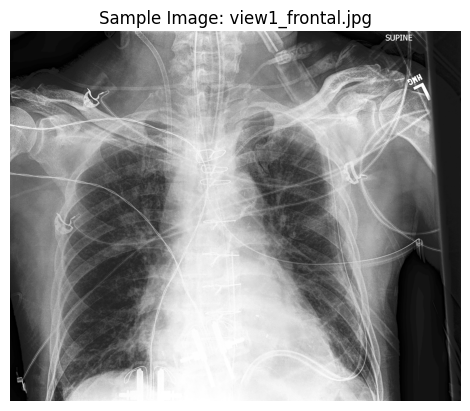

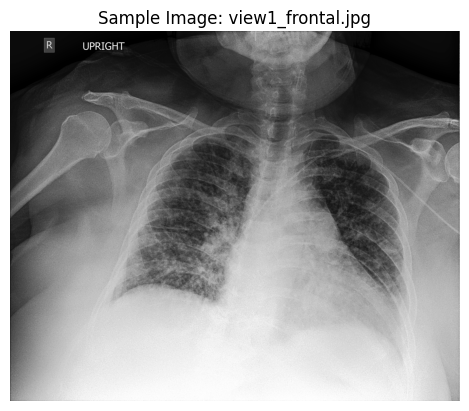

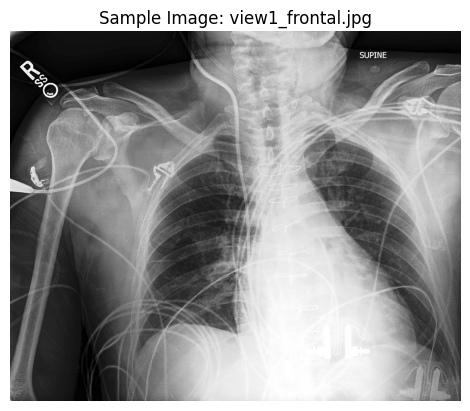

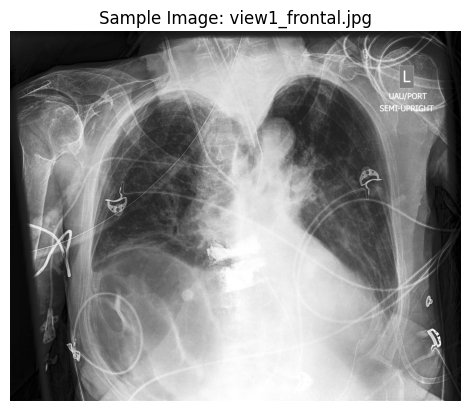

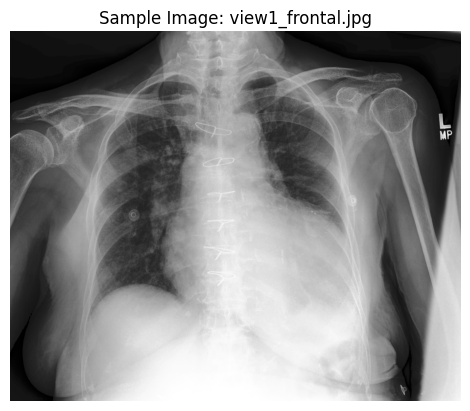

In [117]:
# Display a few sample images
sample_paths = train_df["ImagePath"].sample(5).tolist()

for path in sample_paths:
    if os.path.exists(path):
        # Load the image in grayscale
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        # Plot the image
        plt.imshow(img, cmap="gray")
        plt.title(f"Sample Image: {os.path.basename(path)}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Image not found: {path}")

Text(0.5, 1.0, 'Correlation Matrix of Pathologies')

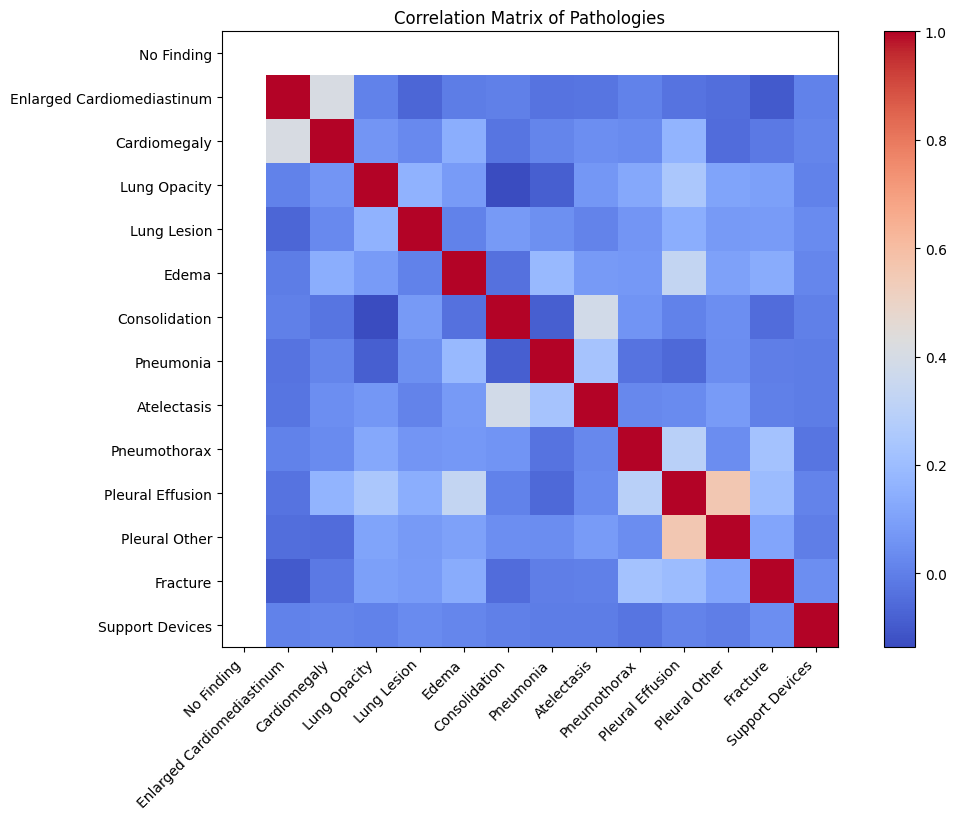

In [118]:
correlation_matrix = train_df[conditions].corr()

# Plot heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="none")
plt.colorbar()
plt.xticks(range(len(conditions)), conditions, rotation=45, ha="right")
plt.yticks(range(len(conditions)), conditions)
plt.title("Correlation Matrix of Pathologies")

In [119]:
# Find the strongest correlations
strong_corrs = correlation_matrix.unstack().sort_values(ascending=False)
print("Strongest Correlations:")
print(strong_corrs[strong_corrs < 1].head(10))  # Exclude self-correlations

Strongest Correlations:
Pleural Effusion            Pleural Other                 0.559097
Pleural Other               Pleural Effusion              0.559097
Enlarged Cardiomediastinum  Cardiomegaly                  0.406148
Cardiomegaly                Enlarged Cardiomediastinum    0.406148
Atelectasis                 Consolidation                 0.383346
Consolidation               Atelectasis                   0.383346
Edema                       Pleural Effusion              0.330250
Pleural Effusion            Edema                         0.330250
                            Pneumothorax                  0.296794
Pneumothorax                Pleural Effusion              0.296794
dtype: float64


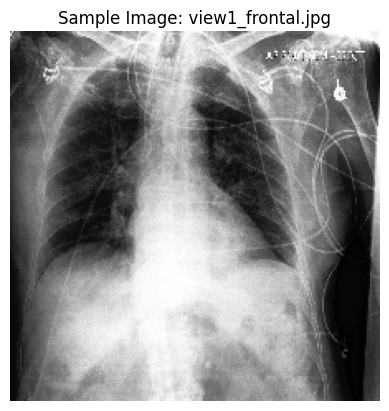

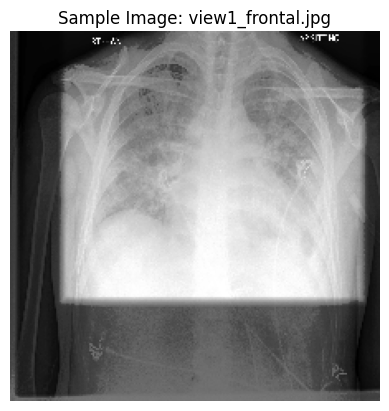

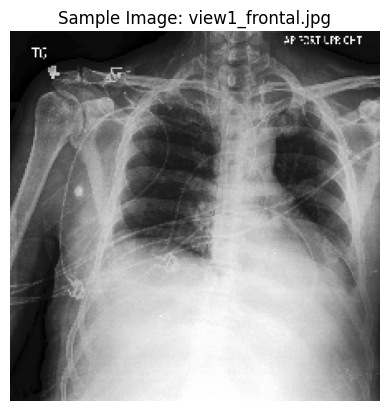

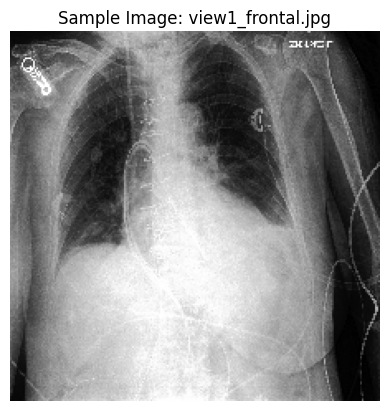

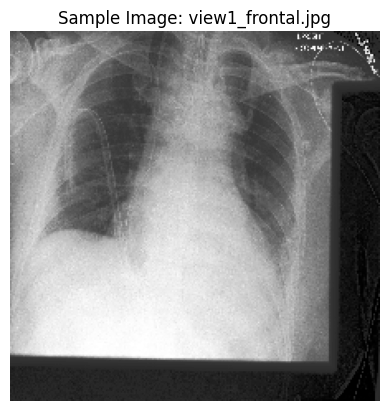

In [120]:
# Resize and normalize a single image
def preprocess_image(image_path, size=(224, 224)):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, size)  # Resize to target size
    img_normalized = img_resized / 255.0  # Normalize pixel values to [0, 1]
    return img_normalized

# Apply preprocessing to a few sample images
sample_paths = train_df["ImagePath"].sample(5).tolist()

for path in sample_paths:
    if os.path.exists(path):
        img = preprocess_image(path)
        plt.imshow(img, cmap="gray")
        plt.title(f"Sample Image: {os.path.basename(path)}")
        plt.axis("off")
        plt.show()
    else:
        print(f"Image not found: {path}")

### Blurriness/Sharpness

In [121]:
# Function to calculate blurriness using Laplacian variance
def calculate_blurriness(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None  # Handle missing or invalid images
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var

# Apply to a few sample images
sample_images = train_df["ImagePath"].sample(5).tolist()
for path in sample_images:
    blurriness = calculate_blurriness(path)
    print(f"Image: {path}, Blurriness: {blurriness}")

Image: S:\chexpert\chexpert-data\train_images\patient05614\study3\view1_frontal.jpg, Blurriness: 477.04038500508125
Image: S:\chexpert\chexpert-data\train_images\patient34441\study5\view1_frontal.jpg, Blurriness: 660.9293165443894
Image: S:\chexpert\chexpert-data\train_images\patient09340\study4\view2_lateral.jpg, Blurriness: 275.98891579889937
Image: S:\chexpert\chexpert-data\train_images\patient35725\study7\view2_lateral.jpg, Blurriness: 156.39341641352885
Image: S:\chexpert\chexpert-data\train_images\patient27983\study37\view1_frontal.jpg, Blurriness: 218.22324370104823


### Brightness and Contrast (Exposure)

In [63]:
# Function to calculate brightness and contrast
def calculate_brightness_contrast(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None  # Handle missing or invalid images
    brightness = np.mean(img)  # Mean pixel value
    contrast = np.std(img)    # Standard deviation of pixel values
    return brightness, contrast

# Apply to a few sample images
for path in sample_images:
    brightness, contrast = calculate_brightness_contrast(path)
    print(f"Image: {path}, Brightness: {brightness}, Contrast: {contrast}")

Image: S:\chexpert\chexpert-data\batch1\valid\patient64600/study1/view2_lateral.jpg, Brightness: 128.79387025679168, Contrast: 73.84626368738144
Image: S:\chexpert\chexpert-data\batch1\valid\patient64631/study1/view1_frontal.jpg, Brightness: 129.07439155245575, Contrast: 73.94468391624234
Image: S:\chexpert\chexpert-data\batch1\valid\patient64705/study1/view2_lateral.jpg, Brightness: 128.98403404379846, Contrast: 73.88600927300118
Image: S:\chexpert\chexpert-data\batch1\valid\patient64719/study1/view1_frontal.jpg, Brightness: 129.1268637516461, Contrast: 73.69663244916774
Image: S:\chexpert\chexpert-data\batch1\valid\patient64655/study1/view1_frontal.jpg, Brightness: 129.2893193983807, Contrast: 73.74287225621904


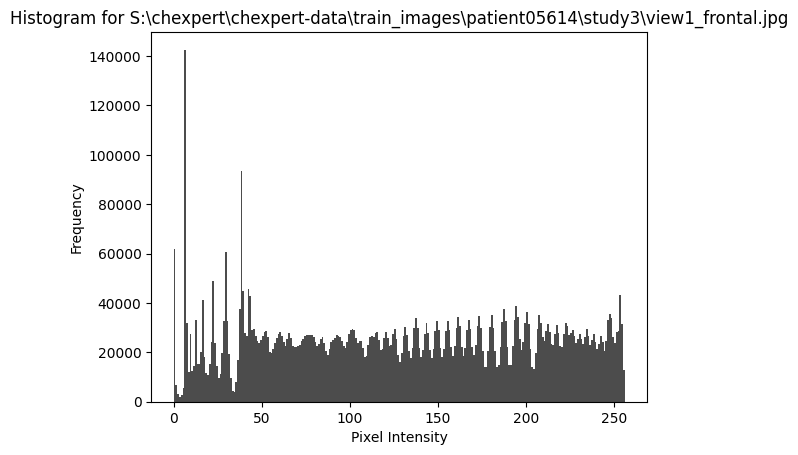

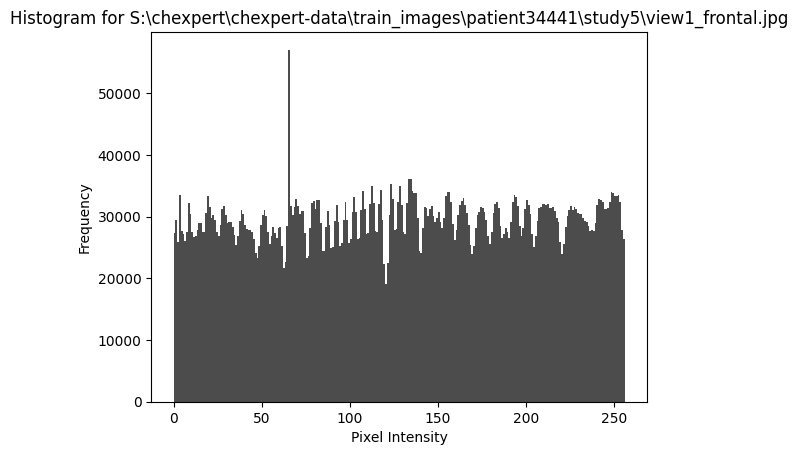

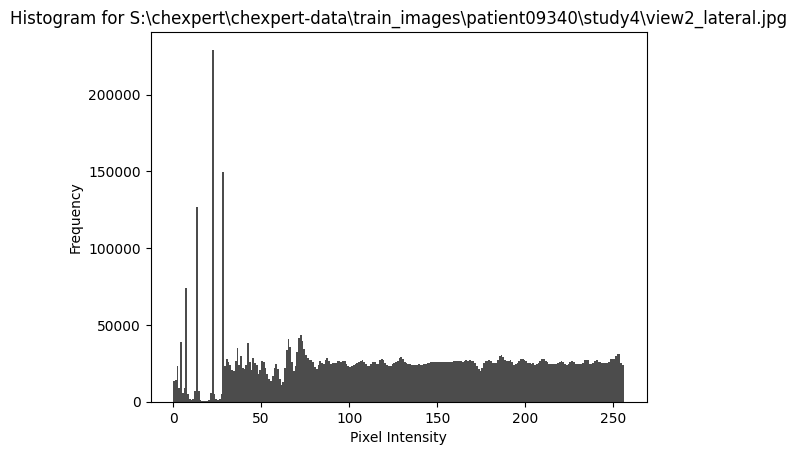

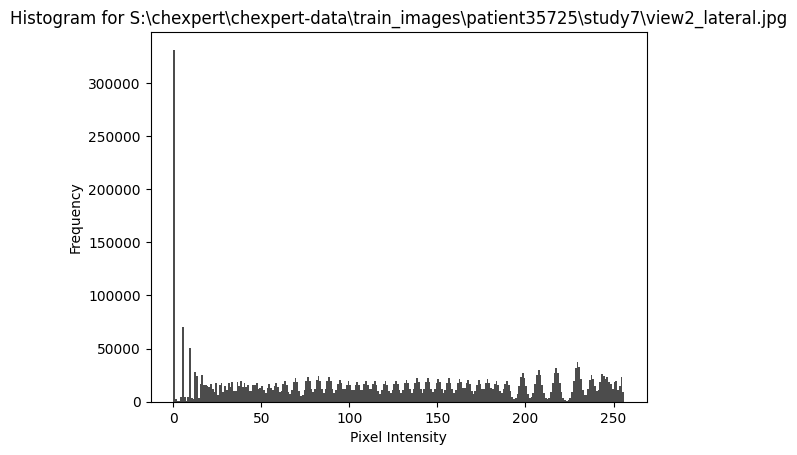

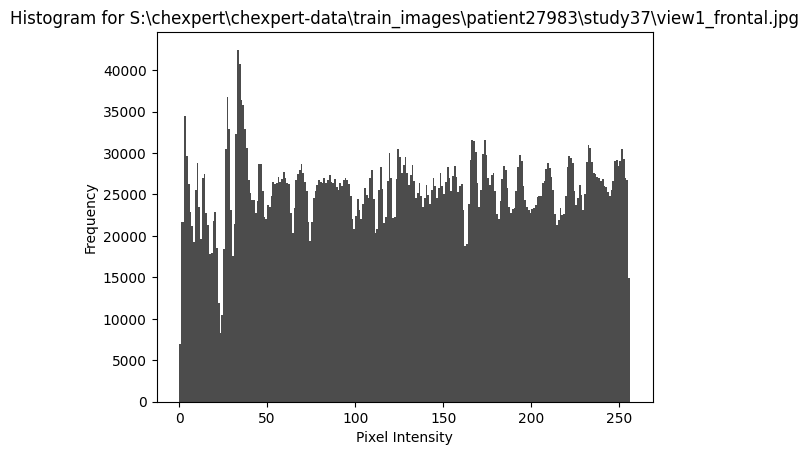

In [122]:
# Function to plot histogram
def plot_histogram(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Invalid image: {image_path}")
        return
    plt.hist(img.ravel(), bins=256, range=(0, 256), color='black', alpha=0.7)
    plt.title(f"Histogram for {image_path}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    plt.show()

# Plot histograms for sample images
for path in sample_images:
    plot_histogram(path)

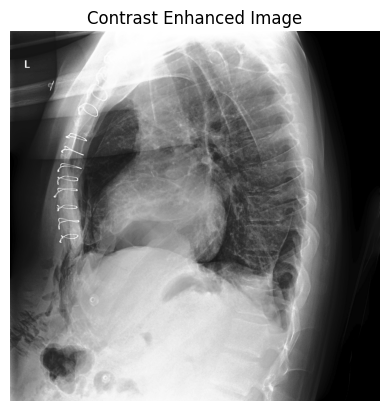

In [125]:
# Apply histogram equalization
def enhance_contrast(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img_eq = cv2.equalizeHist(img)
    return img_eq

enhanced_img = enhance_contrast("S:\\chexpert\\chexpert-data\\train_images\\patient35725\\study7\\view2_lateral.jpg")
plt.imshow(enhanced_img, cmap="gray")
plt.title("Contrast Enhanced Image")
plt.axis("off")
plt.show()

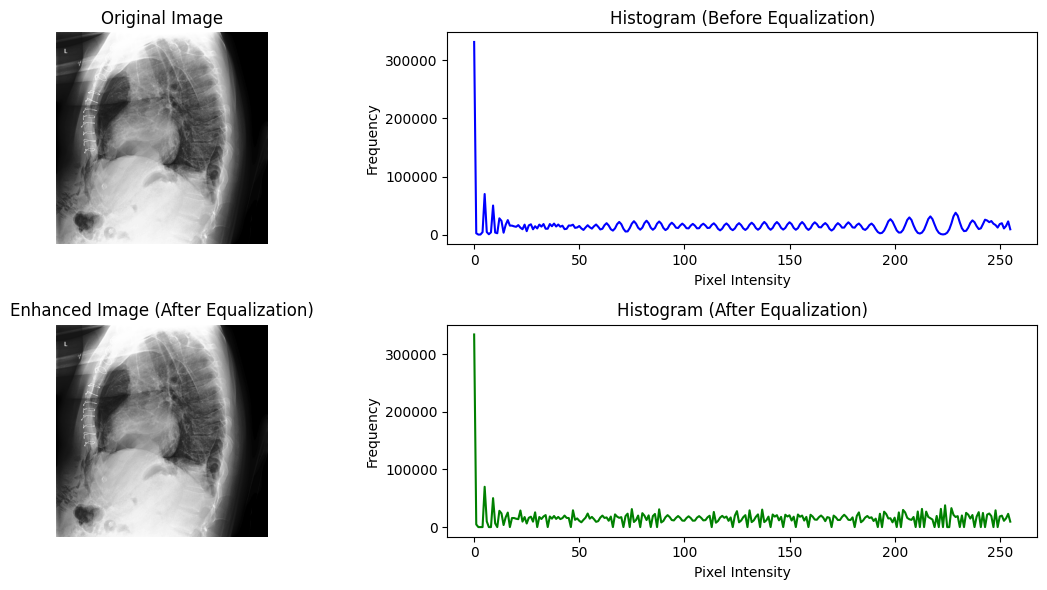

In [126]:
# Function to enhance contrast and plot histograms
def enhance_contrast_and_plot_histograms(image_path):
    # Read the image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Compute the histogram before equalization
    hist_before = cv2.calcHist([img], [0], None, [256], [0, 256])

    # Apply histogram equalization
    img_eq = cv2.equalizeHist(img)

    # Compute the histogram after equalization
    hist_after = cv2.calcHist([img_eq], [0], None, [256], [0, 256])

    # Plot the original image and its histogram
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(2, 2, 2)
    plt.plot(hist_before, color="blue")
    plt.title("Histogram (Before Equalization)")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    # Plot the enhanced image and its histogram
    plt.subplot(2, 2, 3)
    plt.imshow(img_eq, cmap="gray")
    plt.title("Enhanced Image (After Equalization)")
    plt.axis("off")
    
    plt.subplot(2, 2, 4)
    plt.plot(hist_after, color="green")
    plt.title("Histogram (After Equalization)")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

# Test the function
image_path = "S:\\chexpert\\chexpert-data\\train_images\\patient35725\\study7\\view2_lateral.jpg"
enhance_contrast_and_plot_histograms(image_path)

Original Image - Brightness: 119.6308665004587, Contrast: 79.73449187885394
Equalized Image - Brightness: 117.7433893646646, Contrast: 78.74695751600939


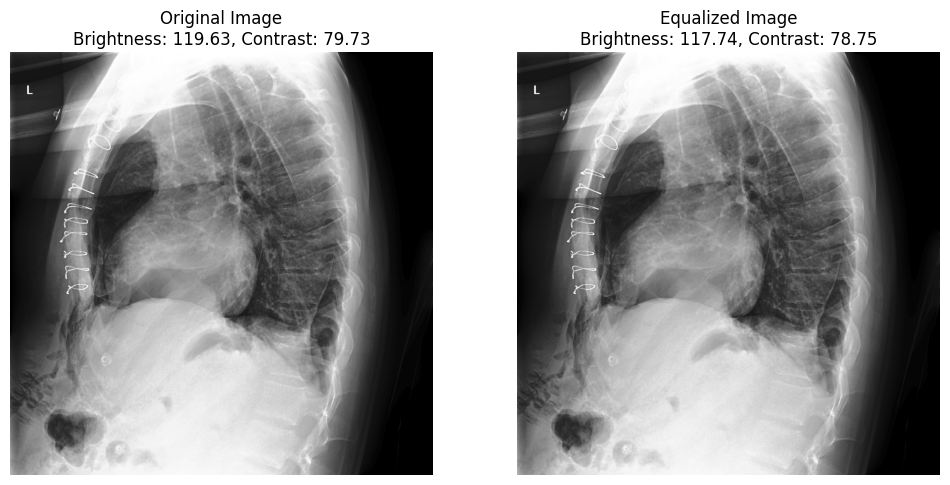

In [127]:
# Load the image
sample_image_path = r"S:\\chexpert\\chexpert-data\\train_images\\patient35725\\study7\\view2_lateral.jpg"
img = cv2.imread(sample_image_path, cv2.IMREAD_GRAYSCALE)

# Apply histogram equalization
img_eq = cv2.equalizeHist(img)

# Calculate brightness and contrast
def calculate_brightness_contrast(image):
    brightness = np.mean(image)  # Mean pixel intensity
    contrast = np.std(image)    # Standard deviation of pixel intensities
    return brightness, contrast

# Compute values for original and equalized images
original_brightness, original_contrast = calculate_brightness_contrast(img)
equalized_brightness, equalized_contrast = calculate_brightness_contrast(img_eq)

# Display results
print(f"Original Image - Brightness: {original_brightness}, Contrast: {original_contrast}")
print(f"Equalized Image - Brightness: {equalized_brightness}, Contrast: {equalized_contrast}")

# Plot the images side by side
plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title(f"Original Image\nBrightness: {original_brightness:.2f}, Contrast: {original_contrast:.2f}")
plt.axis("off")

# Equalized Image
plt.subplot(1, 2, 2)
plt.imshow(img_eq, cmap="gray")
plt.title(f"Equalized Image\nBrightness: {equalized_brightness:.2f}, Contrast: {equalized_contrast:.2f}")
plt.axis("off")

plt.show()

In [37]:
def evaluate_exposure(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    
    # Calculate the percentage of pixels in the extreme ranges (underexposed or overexposed)
    low_end = hist[:30].sum()  # Low pixel values (dark areas)
    high_end = hist[225:].sum()  # High pixel values (bright areas)
    total_pixels = hist.sum()

    # Exposure ratios
    low_ratio = low_end / total_pixels
    high_ratio = high_end / total_pixels
    
    return low_ratio, high_ratio

# Check exposure for a few sample images
for path in sample_images:
    low_ratio, high_ratio = evaluate_exposure(path)
    print(f"Image: {path}, Low Exposure Ratio: {low_ratio}, High Exposure Ratio: {high_ratio}")

Image: S:\chexpert\chexpert-data\batch1\valid\patient64709/study1/view1_frontal.jpg, Low Exposure Ratio: 0.09816332906484604, High Exposure Ratio: 0.12743748724460602
Image: S:\chexpert\chexpert-data\batch1\valid\patient64727/study1/view1_frontal.jpg, Low Exposure Ratio: 0.11224394291639328, High Exposure Ratio: 0.1241941750049591
Image: S:\chexpert\chexpert-data\batch1\valid\patient64567/study1/view2_lateral.jpg, Low Exposure Ratio: 0.10728587210178375, High Exposure Ratio: 0.1297733336687088
Image: S:\chexpert\chexpert-data\batch1\valid\patient64556/study1/view1_frontal.jpg, Low Exposure Ratio: 0.10960642993450165, High Exposure Ratio: 0.15330469608306885
Image: S:\chexpert\chexpert-data\batch1\valid\patient64555/study1/view1_frontal.jpg, Low Exposure Ratio: 0.11239893734455109, High Exposure Ratio: 0.13527698814868927


In [38]:
# Plot contrast distribution
plt.figure(figsize=(12, 6))
plt.hist(valid_df["Contrast"].dropna(), bins=50, alpha=0.7, color="blue")
plt.title("Contrast Distribution")
plt.xlabel("Contrast")
plt.ylabel("Frequency")
plt.legend()

KeyError: 'Contrast'

<Figure size 1200x600 with 0 Axes>

### Test pipeline

In [173]:
# Define the sample size
sample_size = 3000  # Adjust based on your needs

# Take a random sample of rows from train_df
train_sample = train_df.sample(sample_size, random_state=42)

In [174]:
def calculate_quality_metrics(image_path):
    """Compute brightness, contrast, and sharpness for an image."""
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None  # Skip if the image is not found or cannot be loaded

    # Brightness: Mean intensity
    brightness = np.mean(img)

    # Contrast: Standard deviation of pixel intensities
    contrast = np.std(img)

    # Sharpness: Variance of the Laplacian (captures edges and focus)
    sharpness = cv2.Laplacian(img, cv2.CV_64F).var()

    return {"brightness": brightness, "contrast": contrast, "sharpness": sharpness}

In [175]:
# Initialize lists to store metrics
quality_metrics = []

# Iterate over the sampled DataFrame
for idx, row in train_sample.iterrows():
    image_path = row["ImagePath"]
    
    if not row["Exists"]:  # Skip missing images
        print(f"Image not found: {image_path}")
        continue

    # Calculate metrics
    metrics = calculate_quality_metrics(image_path)
    if metrics is None:
        print(f"Metrics could not be calculated for: {image_path}")
        continue

    # Store metrics with the corresponding index
    metrics["index"] = idx
    quality_metrics.append(metrics)

# Convert metrics to a DataFrame and merge with sampled train_df
quality_metrics_df = pd.DataFrame(quality_metrics)  # Ensure metrics are properly stored
train_sample = train_sample.reset_index()
train_sample = pd.merge(train_sample, quality_metrics_df, left_index=True, right_on="index")


In [176]:
quality_metrics_df.head()

,brightness,contrast,sharpness,index
0,128.245801,73.918718,625.925450,305
1,129.163929,73.735666,297.006700,151324
2,96.085350,85.455632,333.209183,19284
3,129.373383,73.789547,1236.204933,165026
4,129.022816,73.736179,362.306463,26786


In [177]:
# Transform the DataFrame to a long format
comparison_df = train_sample.melt(
    id_vars=["Path", "ImagePath", "brightness", "contrast", "sharpness"],
    value_vars=conditions,
    var_name="condition",
    value_name="certainty"
)

# Drop rows where certainty is NaN
comparison_df = comparison_df.dropna(subset=["certainty"])

In [178]:
# number of uncertain labels in comparison_df
uncertain_labels = comparison_df[comparison_df["certainty"] == -1]
print("Number of Uncertain Labels:", len(uncertain_labels))

Number of Uncertain Labels: 20


In [179]:
comparison_df.head()

,Path,ImagePath,brightness,contrast,sharpness,condition,certainty
3,CheXpert-v1.0/train/patient03504/study4/view1_...,S:\chexpert\chexpert-data\train_images\patient...,129.063128,73.463884,323.010546,No Finding,1.0
7,CheXpert-v1.0/train/patient40443/study9/view1_...,S:\chexpert\chexpert-data\train_images\patient...,130.146923,74.203030,866.974538,No Finding,1.0
15,CheXpert-v1.0/train/patient13660/study1/view2_...,S:\chexpert\chexpert-data\train_images\patient...,130.909494,75.328705,529.217668,No Finding,1.0
19,CheXpert-v1.0/train/patient60014/study1/view1_...,S:\chexpert\chexpert-data\train_images\patient...,129.396080,72.864476,292.688078,No Finding,1.0
25,CheXpert-v1.0/train/patient03271/study2/view1_...,S:\chexpert\chexpert-data\train_images\patient...,129.639275,73.922526,574.266393,No Finding,1.0


In [170]:
print(comparison_df[["brightness", "contrast", "sharpness", "certainty"]].dtypes)


brightness    float64
contrast      float64
sharpness     float64
certainty     float64
dtype: object


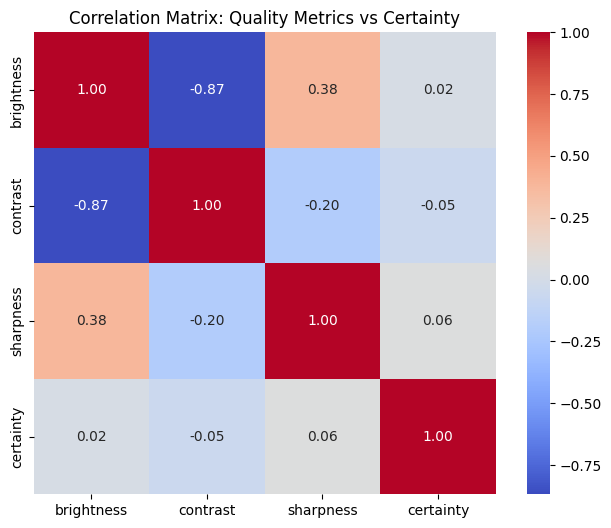

In [180]:
# Compute the correlation matrix
correlation_matrix = comparison_df[["brightness", "contrast", "sharpness", "certainty"]].corr()

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Matrix: Quality Metrics vs Certainty")
plt.show()


C:\Users\soapy\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\soapy\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


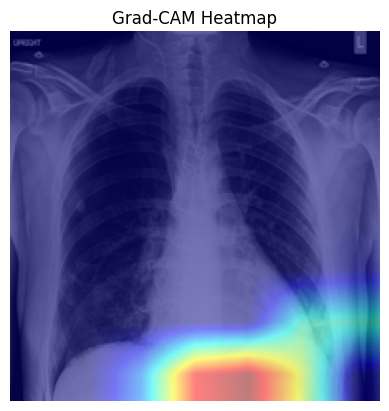

In [210]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2

# Load a pre-trained model
model = models.resnet18(pretrained=True)
model.eval()

# Specify the target layer for Grad-CAM
target_layer = model.layer4[-1]

# Load and preprocess the sample image
sample_image_path = r"S:\\chexpert\\chexpert-data\\train_images\\patient35725\\study7\\view1_frontal.jpg"
image = Image.open(sample_image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to match model input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(image).unsqueeze(0)

# Create the Grad-CAM object
cam = GradCAM(model=model, target_layers=[target_layer])

# Generate heatmap for an "uncertain" class (or any class index, e.g., 0 for binary classification)
targets = [ClassifierOutputTarget(0)]  # Replace '0' with your desired certainty class index
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# Resize the Grad-CAM heatmap to match the input image dimensions
grayscale_cam_resized = cv2.resize(grayscale_cam, (224, 224))

# Display the Grad-CAM heatmap
image_np = np.array(image.resize((224, 224))) / 255.0  # Normalize to [0, 1] range and resize
visualization = show_cam_on_image(image_np, grayscale_cam_resized, use_rgb=True)

# Show the visualization
plt.imshow(visualization)
plt.axis('off')
plt.title("Grad-CAM Heatmap")
plt.show()

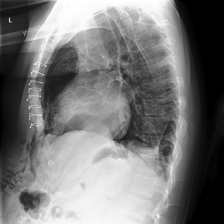

In [204]:
image = Image.open(sample_image_path).convert('RGB')
image = image.resize((224, 224))
image

In [209]:
import shap
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image

# Load a pre-trained model
model = models.resnet18(pretrained=True)
model.eval()

# Load and preprocess an image
image_path = r"S:\\chexpert\\chexpert-data\\train_images\\patient35725\\study7\\view2_lateral.jpg"
image = Image.open(image_path).convert('RGB')
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
input_tensor = transform(image).unsqueeze(0)

# Wrap the model for SHAP
def predict(images):
    images = torch.tensor(images, dtype=torch.float32)
    return model(images).detach().numpy()

# Explain the prediction using SHAP
explainer = shap.GradientExplainer(model, input_tensor)
shap_values, indexes = explainer.shap_values(input_tensor)

# Visualize the SHAP explanations
shap.image_plot(shap_values, input_tensor.numpy())

ImportError: Numba needs NumPy 2.0 or less. Got NumPy 2.1.

In [215]:
#count all labels in the training data
label_counts = train_df[conditions].apply(pd.Series.value_counts).T
label_counts = label_counts.reindex(columns=[0, 1, -1, np.nan])  # Ensure all categories are included
label_counts.columns = ["Negative (0)", "Positive (1)", "Uncertain (-1)", "Unmentioned (NaN)"]

# Display the counts
print("Label Counts in Training Data:")
print(label_counts)

Label Counts in Training Data:
                            Negative (0)  Positive (1)  Uncertain (-1)  \
No Finding                           NaN       22381.0             NaN   
Enlarged Cardiomediastinum       21638.0       10798.0         12403.0   
Cardiomegaly                     11116.0       27000.0          8087.0   
Lung Opacity                      6599.0      105581.0          5598.0   
Lung Lesion                       1270.0        9186.0          1488.0   
Edema                            20726.0       52246.0         12984.0   
Consolidation                    28097.0       14783.0         27742.0   
Pneumonia                         2799.0        6039.0         18770.0   
Atelectasis                       1328.0       33376.0         33739.0   
Pneumothorax                     56341.0       19448.0          3145.0   
Pleural Effusion                 35396.0       86187.0         11628.0   
Pleural Other                      316.0        3523.0          2653.0   
Fractur

In [216]:
label_counts

,Negative (0),Positive (1),Uncertain (-1),Unmentioned (NaN)
No Finding,NaN,22381.0,NaN,NaN
Enlarged Cardiomediastinum,21638.0,10798.0,12403.0,NaN
Cardiomegaly,11116.0,27000.0,8087.0,NaN
Lung Opacity,6599.0,105581.0,5598.0,NaN
Lung Lesion,1270.0,9186.0,1488.0,NaN
Edema,20726.0,52246.0,12984.0,NaN
Consolidation,28097.0,14783.0,27742.0,NaN
Pneumonia,2799.0,6039.0,18770.0,NaN
Atelectasis,1328.0,33376.0,33739.0,NaN
Pneumothorax,56341.0,19448.0,3145.0,NaN
